<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>LLM Engineering Masterclass</h1>
<h1>3. Statistically Rigorous Model Comparison</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
import os
import json
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import watermark
from pydantic import BaseModel
from scipy.stats import binomtest
from tqdm.auto import tqdm
from typing import Literal

# Data downloads/cache and figure output locations
_ROOT = Path.cwd()
_DATA = _ROOT / "data"
_OUT = _ROOT / "output"
_DATA.mkdir(parents=True, exist_ok=True)
_OUT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", str(_DATA / "huggingface"))
os.environ.setdefault("HF_DATASETS_CACHE", str(_DATA / "huggingface" / "datasets"))
os.environ.setdefault("KAGGLEHUB_CACHE", str(_DATA / "kagglehub"))

from collections import Counter
from pprint import pprint

%load_ext watermark
%matplotlib inline

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.17.1

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.6.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: a1c986090a5c99e2014c7651bb71d8130e7ae0fc

json      : 2.0.9
matplotlib: 3.11.1
numpy     : 2.5.3
pandas    : 3.0.5
pydantic  : 2.13.5
scipy     : 1.18.1
tqdm      : 4.70.1
watermark : 2.6.0



In [3]:
plt.style.use("d4sci.mplstyle")
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# The new model looks better

Model A scores 0.83. Model B scores 0.87. Ship B?

On 77 examples that gap fits comfortably inside sampling noise. Teams make five figure model decisions on differences a coin flip could produce. This notebook gives you three tools that settle the question: bootstrap confidence intervals, paired tests and a cost column.

# Load the golden set and prompt from Notebook 2

In [4]:
taxonomy = json.loads((_DATA / "banking77_taxonomy.json").read_text())
QUEUES, INTENTS = taxonomy["queues"], taxonomy["intents"]
prompt = json.loads((_ROOT / "prompts" / "triage_v1.0.0.json").read_text())
golden = pd.read_json(_DATA / "golden_banking77.jsonl", lines=True)
print(len(golden), "golden messages loaded")

77 golden messages loaded


In [5]:
# Condensed from Notebook 2: run one model over the golden set.
from openai import OpenAI

openai_client = OpenAI()

class Triage(BaseModel):
    queue: Literal[tuple(QUEUES)]
    intent: Literal[tuple(INTENTS)]
    summary: str
    requires_human: bool

def render(prompt, text):
    return [
        {"role": "system", "content": prompt["system"]},
        {"role": "user", "content": prompt["user_template"].format(text=text, intents=", ".join(INTENTS))},
    ]

def triage_once(text, model):
    response = openai_client.chat.completions.parse(
        model=model, messages=render(prompt, text), response_format=Triage, temperature=0,
    )
    usage = response.usage
    return response.choices[0].message.parsed, usage.prompt_tokens, usage.completion_tokens

def pmap(fn, items, workers=8):
    with ThreadPoolExecutor(max_workers=workers) as pool:
        return list(tqdm(pool.map(fn, items), total=len(items)))

def evaluate_model(model):
    def score(row):
        start = time.perf_counter()
        prediction, tokens_in, tokens_out = triage_once(row["text"], model)
        return {
            "id": row["id"],
            "queue_ok": int(prediction.queue == row["queue"]),
            "intent_ok": int(prediction.intent == row["intent"]),
            "tokens_in": tokens_in,
            "tokens_out": tokens_out,
            "latency_s": time.perf_counter() - start,
        }
    return pd.DataFrame(pmap(score, golden.to_dict("records"))).set_index("id")

# The bakeoff

In [6]:
MODEL_A = "gpt-4.1-mini"
MODEL_B = "gpt-4.1-nano"  # A quarter of the price. Is it good enough?

results_a = evaluate_model(MODEL_A)
results_b = evaluate_model(MODEL_B)

summary = pd.DataFrame({
    MODEL_A: results_a[["queue_ok", "intent_ok"]].mean(),
    MODEL_B: results_b[["queue_ok", "intent_ok"]].mean(),
}).round(3)
summary

  0%|          | 0/77 [00:00<?, ?it/s]

  0%|          | 0/77 [00:00<?, ?it/s]

,gpt-4.1-mini,gpt-4.1-nano
queue_ok,0.792,0.662
intent_ok,0.753,0.558


One number per model invites a bad decision. The question is not which number is bigger. The question is whether the gap survives resampling.

We compare on intent accuracy from here on. The six way routing task is close to saturated for both models. The 77 way task is where they differ.

# Bootstrap confidence intervals

Resample the per item scores with replacement, many times. The spread of the resampled means shows how much the accuracy moves under sampling noise. No distributional assumptions, 10 lines of numpy.

In [7]:
METRIC = "intent_ok"  # The 77 way task. Harder, so the models separate more.

rng = np.random.default_rng(20260912)

def bootstrap_means(values, n_boot=10_000):
    """Resample with replacement. Return the distribution of the mean."""
    values = np.asarray(values)
    idx = rng.integers(0, len(values), size=(n_boot, len(values)))
    return values[idx].mean(axis=1)

boots_a = bootstrap_means(results_a[METRIC])
boots_b = bootstrap_means(results_b[METRIC])

accuracy_a = results_a[METRIC].mean()
accuracy_b = results_b[METRIC].mean()

ci_a = np.quantile(boots_a, [0.025, 0.975])
ci_b = np.quantile(boots_b, [0.025, 0.975])

print(f"{MODEL_A}: {accuracy_a:.3f}  95% CI [{ci_a[0]:.3f}, {ci_a[1]:.3f}]")
print(f"{MODEL_B}: {accuracy_b:.3f}  95% CI [{ci_b[0]:.3f}, {ci_b[1]:.3f}]")

gpt-4.1-mini: 0.753  95% CI [0.649, 0.844]
gpt-4.1-nano: 0.558  95% CI [0.442, 0.663]


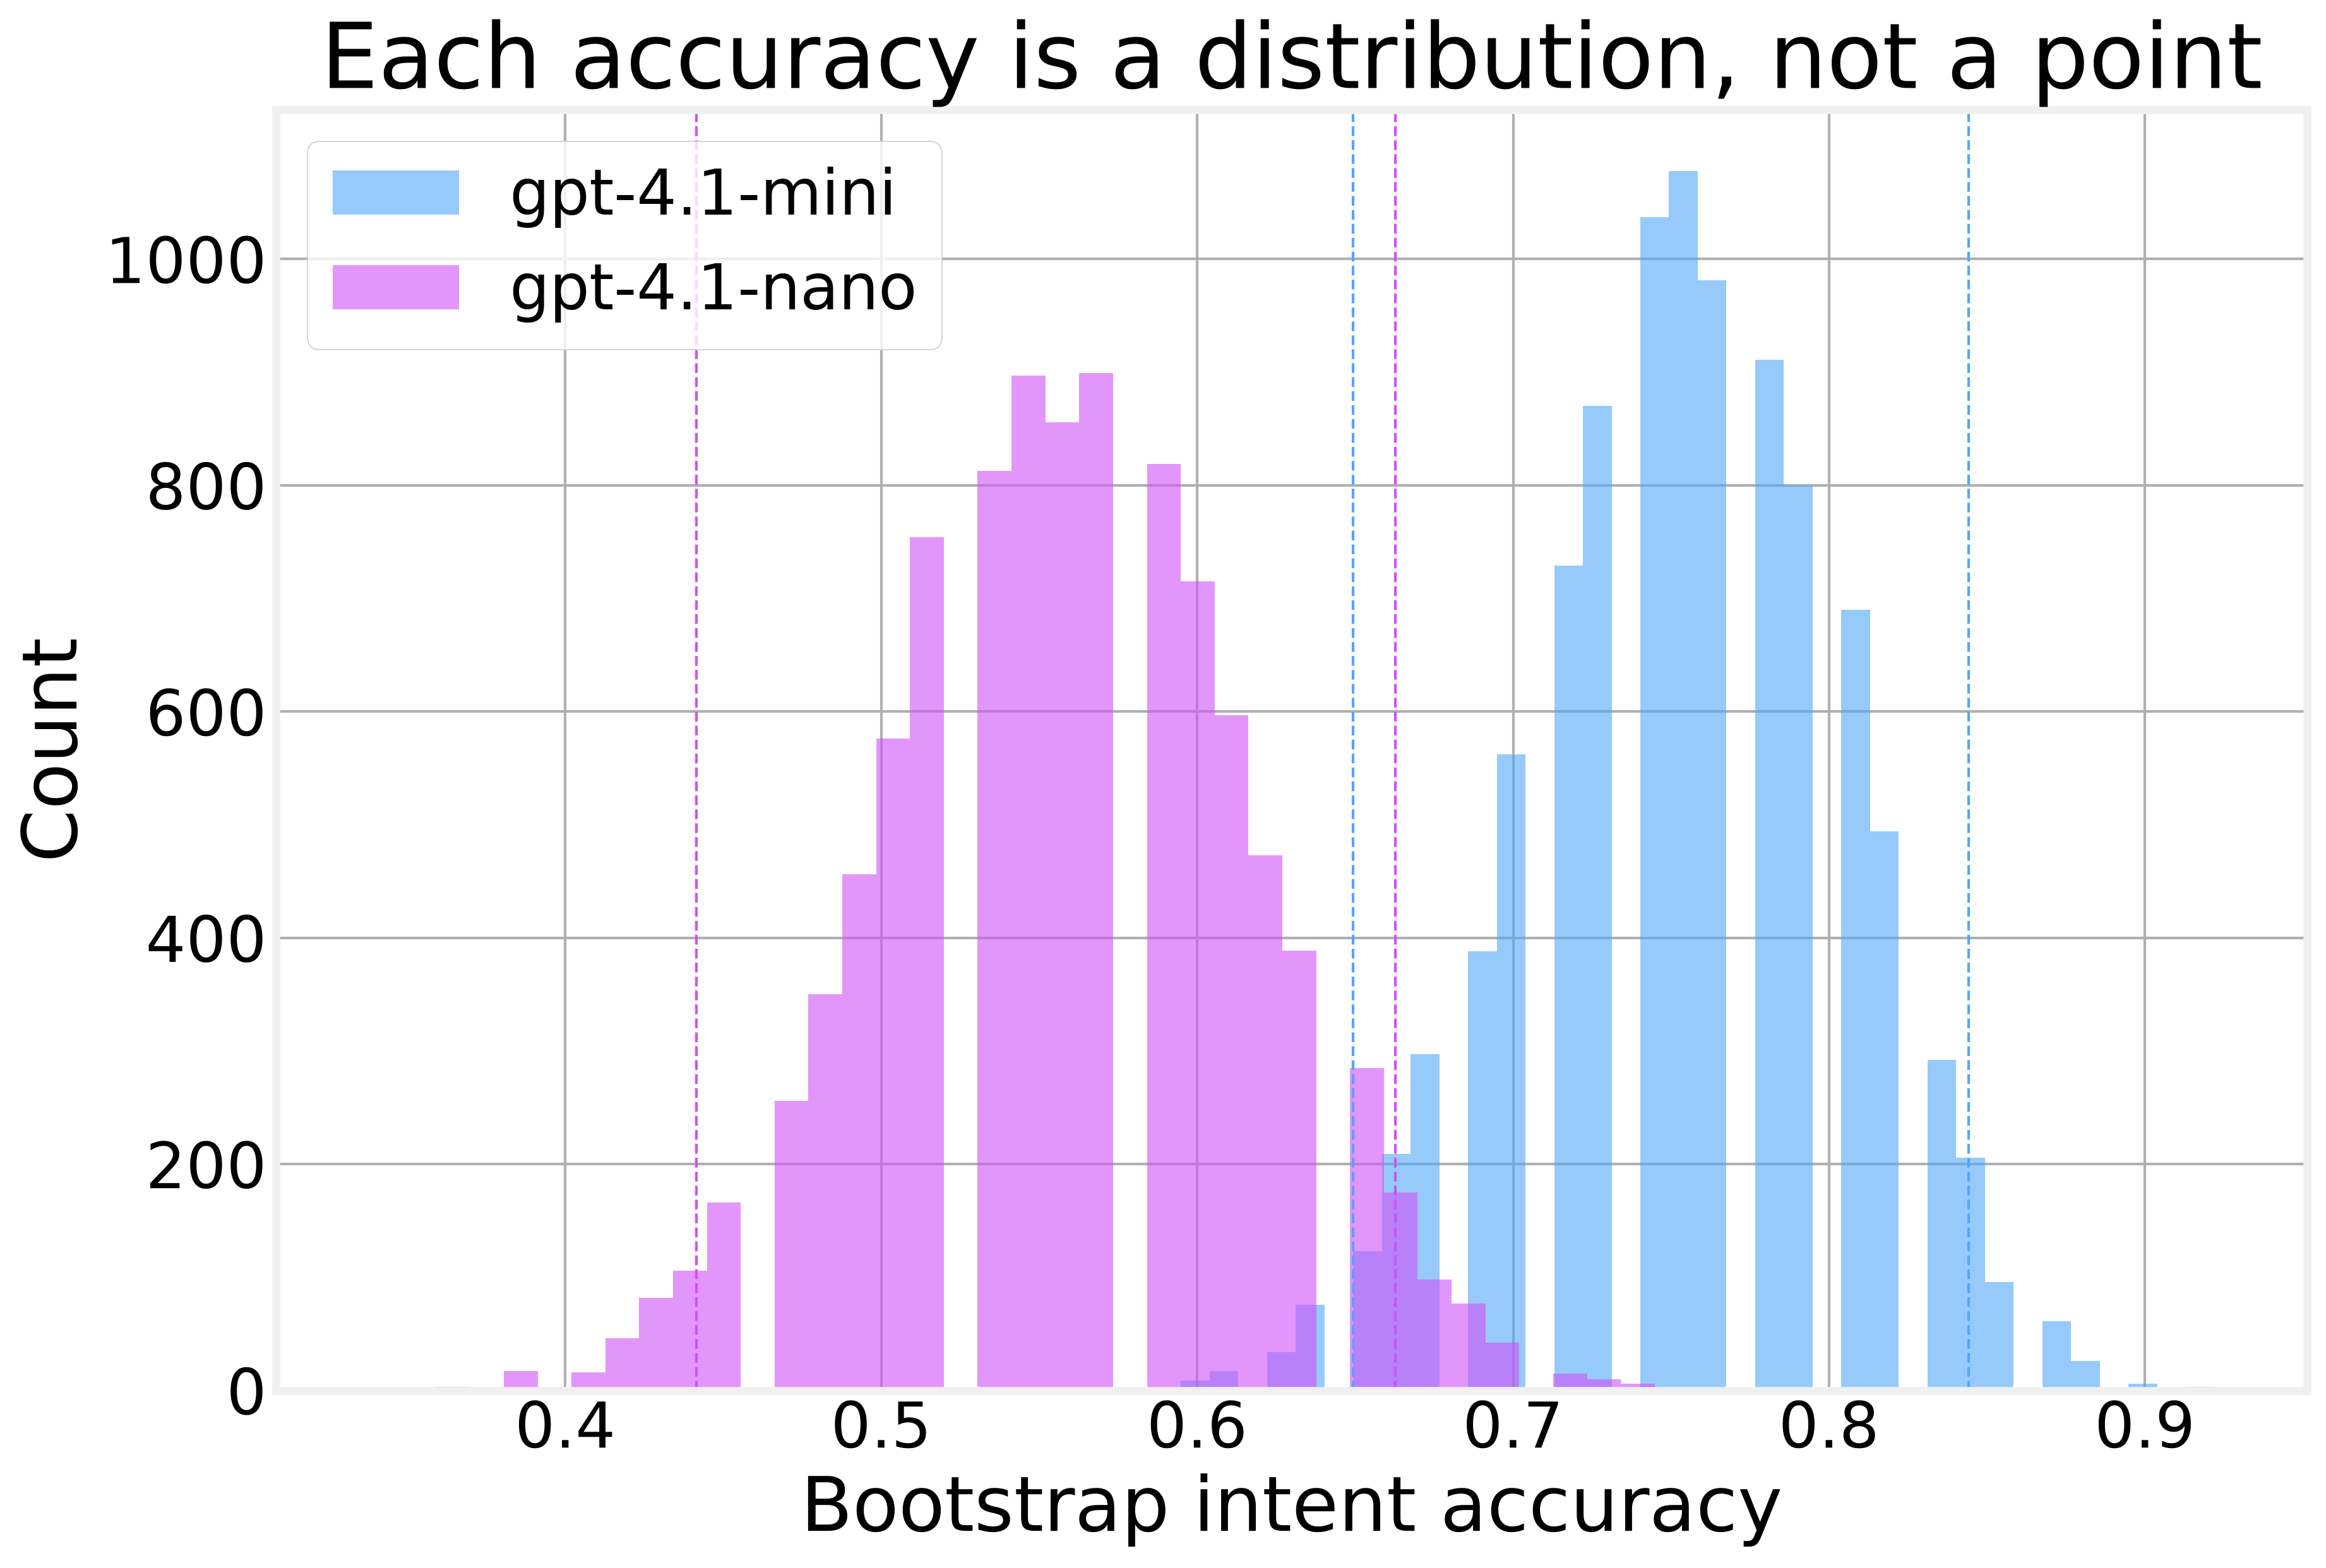

In [8]:
fig, ax = plt.subplots()
ax.hist(boots_a, bins=40, alpha=0.6, color=colors[0], label=MODEL_A)
ax.hist(boots_b, bins=40, alpha=0.6, color=colors[1], label=MODEL_B)
for bound in ci_a:
    ax.axvline(bound, color=colors[0], linestyle="--", linewidth=1)
for bound in ci_b:
    ax.axvline(bound, color=colors[1], linestyle="--", linewidth=1)
ax.set_xlabel("Bootstrap intent accuracy")
ax.set_ylabel("Count")
ax.set_title("Each accuracy is a distribution, not a point")
ax.legend()
fig.tight_layout()

# Pair the comparison

Both models saw the same 77 messages. Comparing separate intervals throws that away. Score the difference per item instead: shared item difficulty cancels and the interval tightens.

A note on reading intervals: two overlapping CIs do not prove the models tie. The paired difference answers the real question.

Mean paired difference: +0.195
95% CI [+0.091, +0.299]


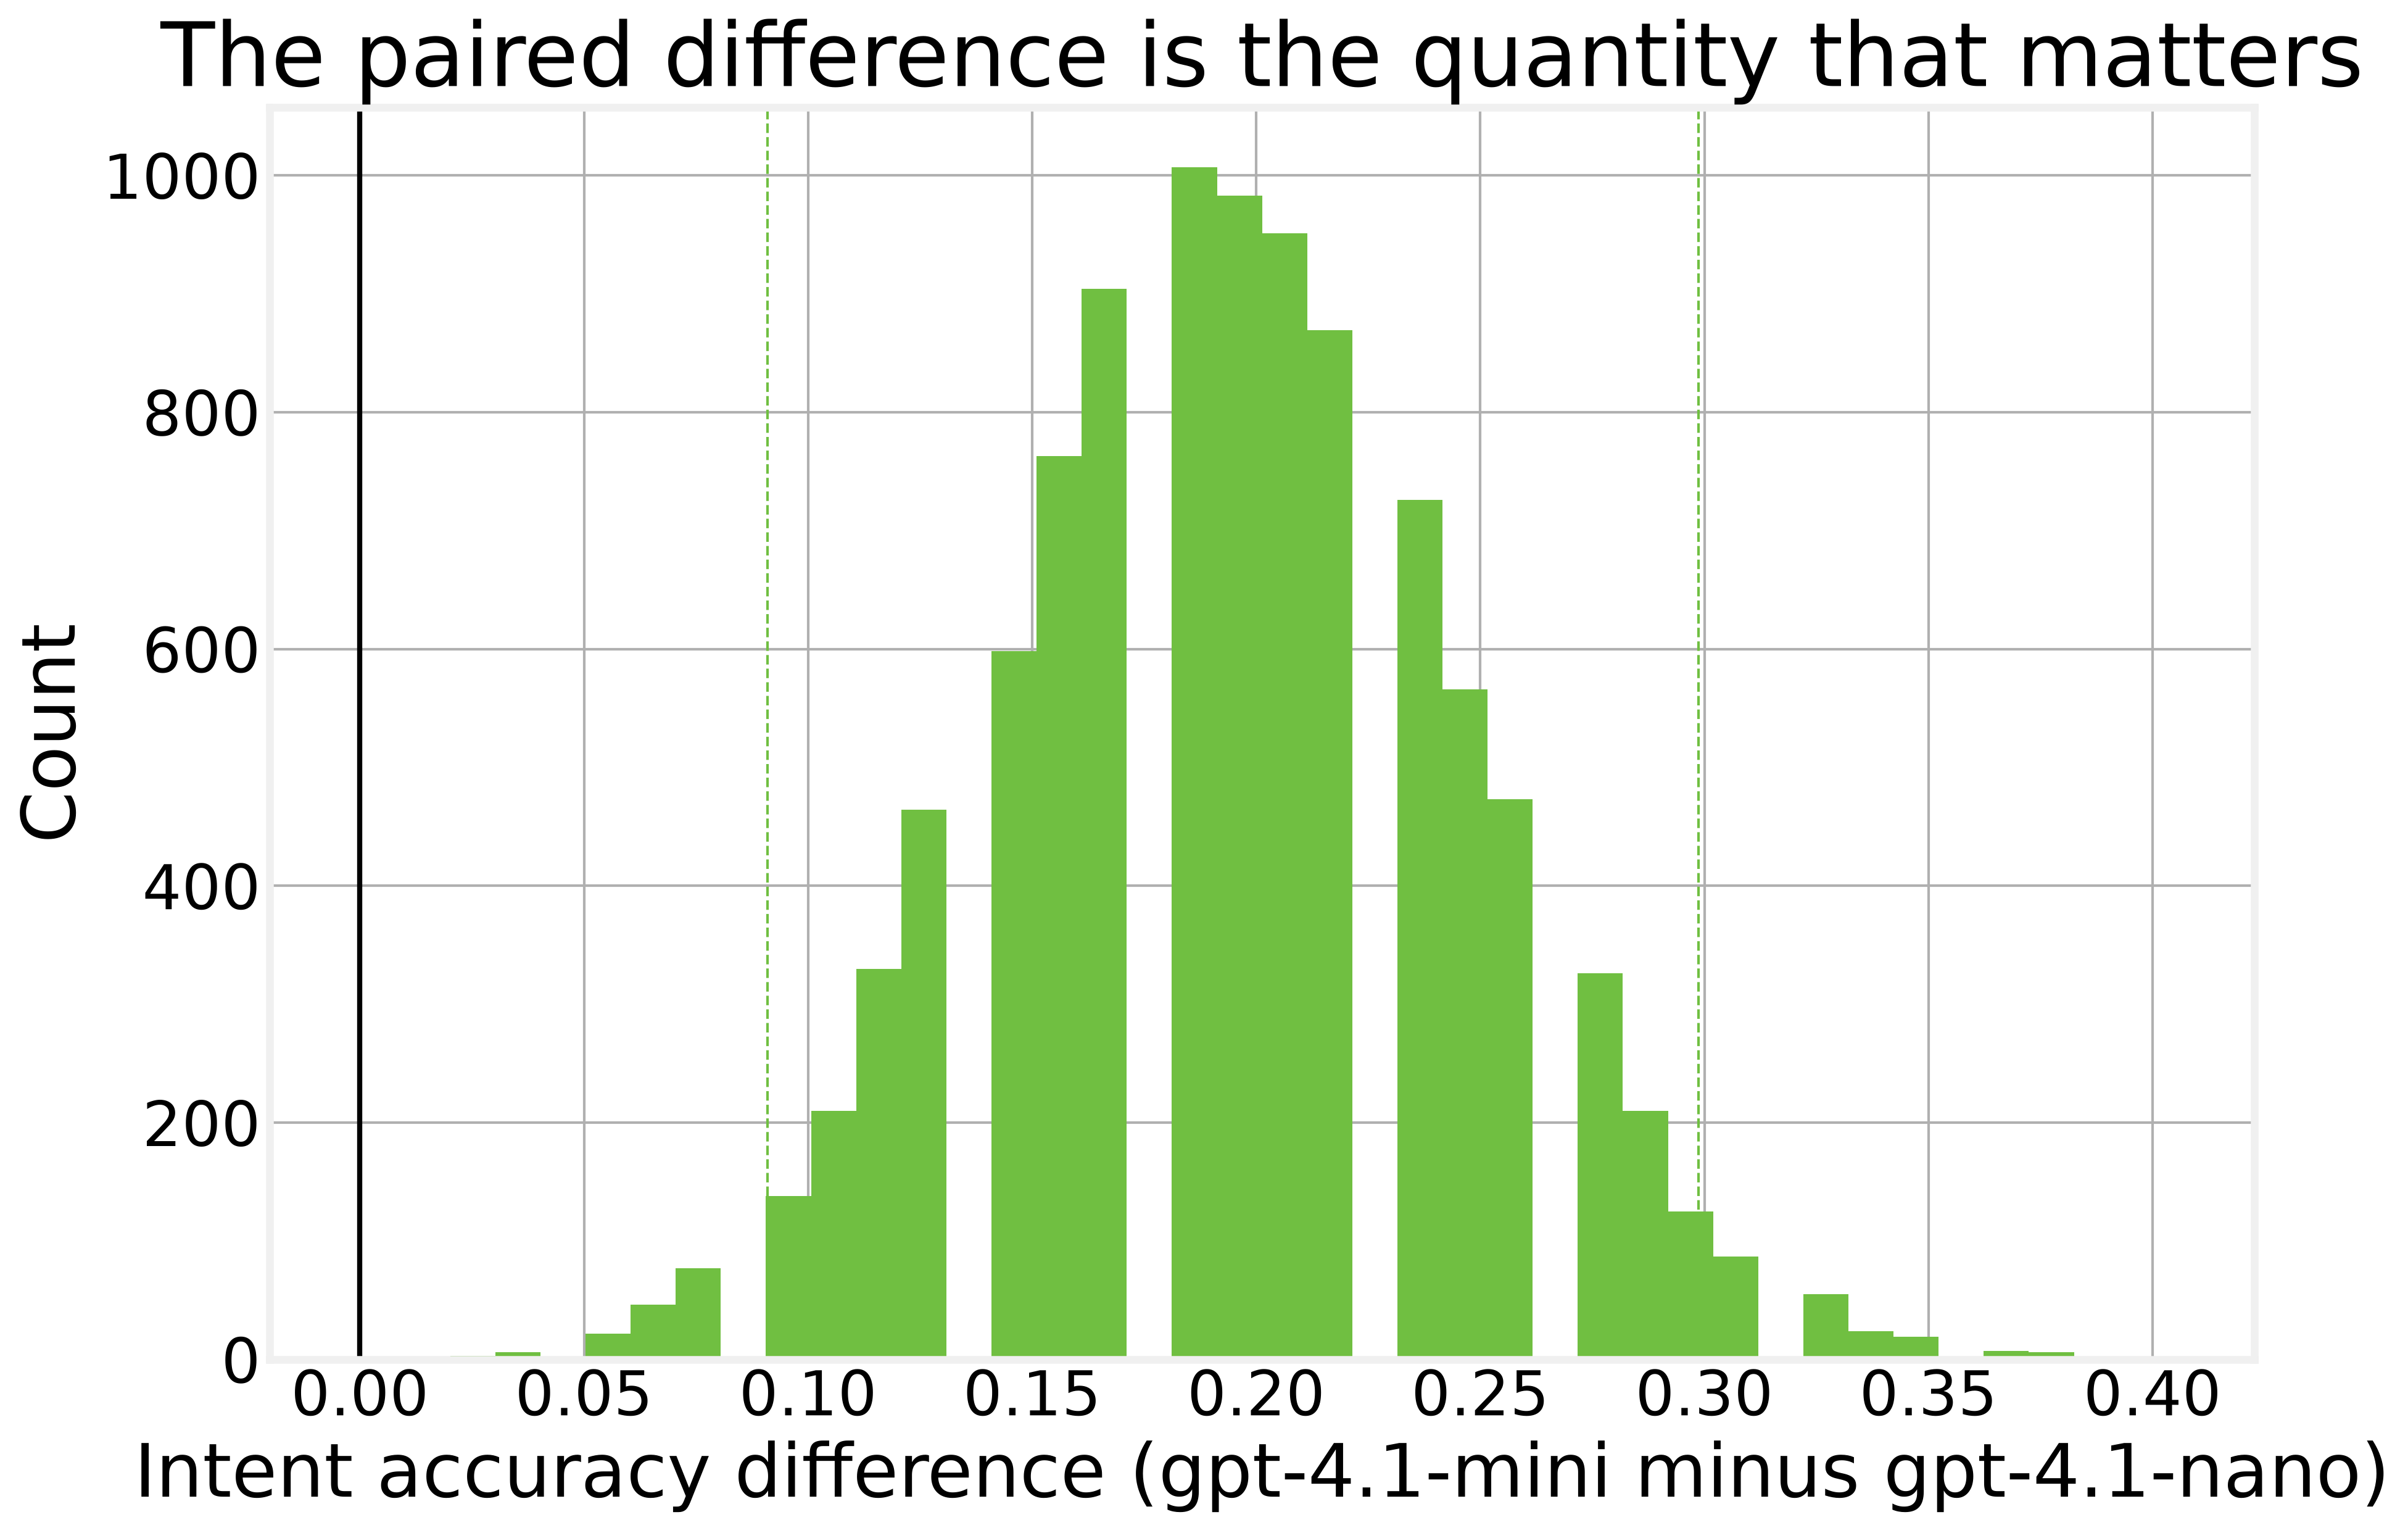

In [9]:
delta = results_a[METRIC].to_numpy() - results_b[METRIC].to_numpy()
boots_delta = bootstrap_means(delta)
ci_delta = np.quantile(boots_delta, [0.025, 0.975])

print(f"Mean paired difference: {delta.mean():+.3f}")
print(f"95% CI [{ci_delta[0]:+.3f}, {ci_delta[1]:+.3f}]")

fig, ax = plt.subplots()
ax.hist(boots_delta, bins=40, color=colors[2])
ax.axvline(0, color="black", linewidth=2)
for bound in ci_delta:
    ax.axvline(bound, color=colors[2], linestyle="--", linewidth=1)
ax.set_xlabel(f"Intent accuracy difference ({MODEL_A} minus {MODEL_B})")
ax.set_ylabel("Count")
ax.set_title("The paired difference is the quantity that matters")
fig.tight_layout()

### A classical check: McNemar's exact test

For paired binary outcomes, only the disagreements carry information. Count them and ask the binomial.

In [10]:
both = results_a[[METRIC]].join(results_b[[METRIC]], rsuffix="_b")
b = int(((both[METRIC] == 1) & (both[METRIC + "_b"] == 0)).sum())
c = int(((both[METRIC] == 0) & (both[METRIC + "_b"] == 1)).sum())

print(f"{MODEL_A} right, {MODEL_B} wrong: {b}")
print(f"{MODEL_B} right, {MODEL_A} wrong: {c}")

if b + c:
    p_value = binomtest(min(b, c), b + c, 0.5).pvalue
    print(f"McNemar exact p value: {p_value:.3f}")
else:
    print("The models agree on every item. No test needed.")


gpt-4.1-mini right, gpt-4.1-nano wrong: 17
gpt-4.1-nano right, gpt-4.1-mini wrong: 2
McNemar exact p value: 0.001


### How to read the result

1. The CI excludes zero and the p value is small: the gap is real. Weigh it against cost.
2. The CI contains zero: n=77 cannot separate these models. Grow the golden set or take the cheaper model.

Both outcomes are wins. One gives you a defensible upgrade. The other saves you money.

# How many examples would you need?

With Banking77 the answer is affordable. The full test split is 3,080 messages. Both models over all of it costs about a dollar.

,n,ci_width
0,77,0.195
1,200,0.120
2,500,0.078
3,1000,0.053
4,3080,0.032


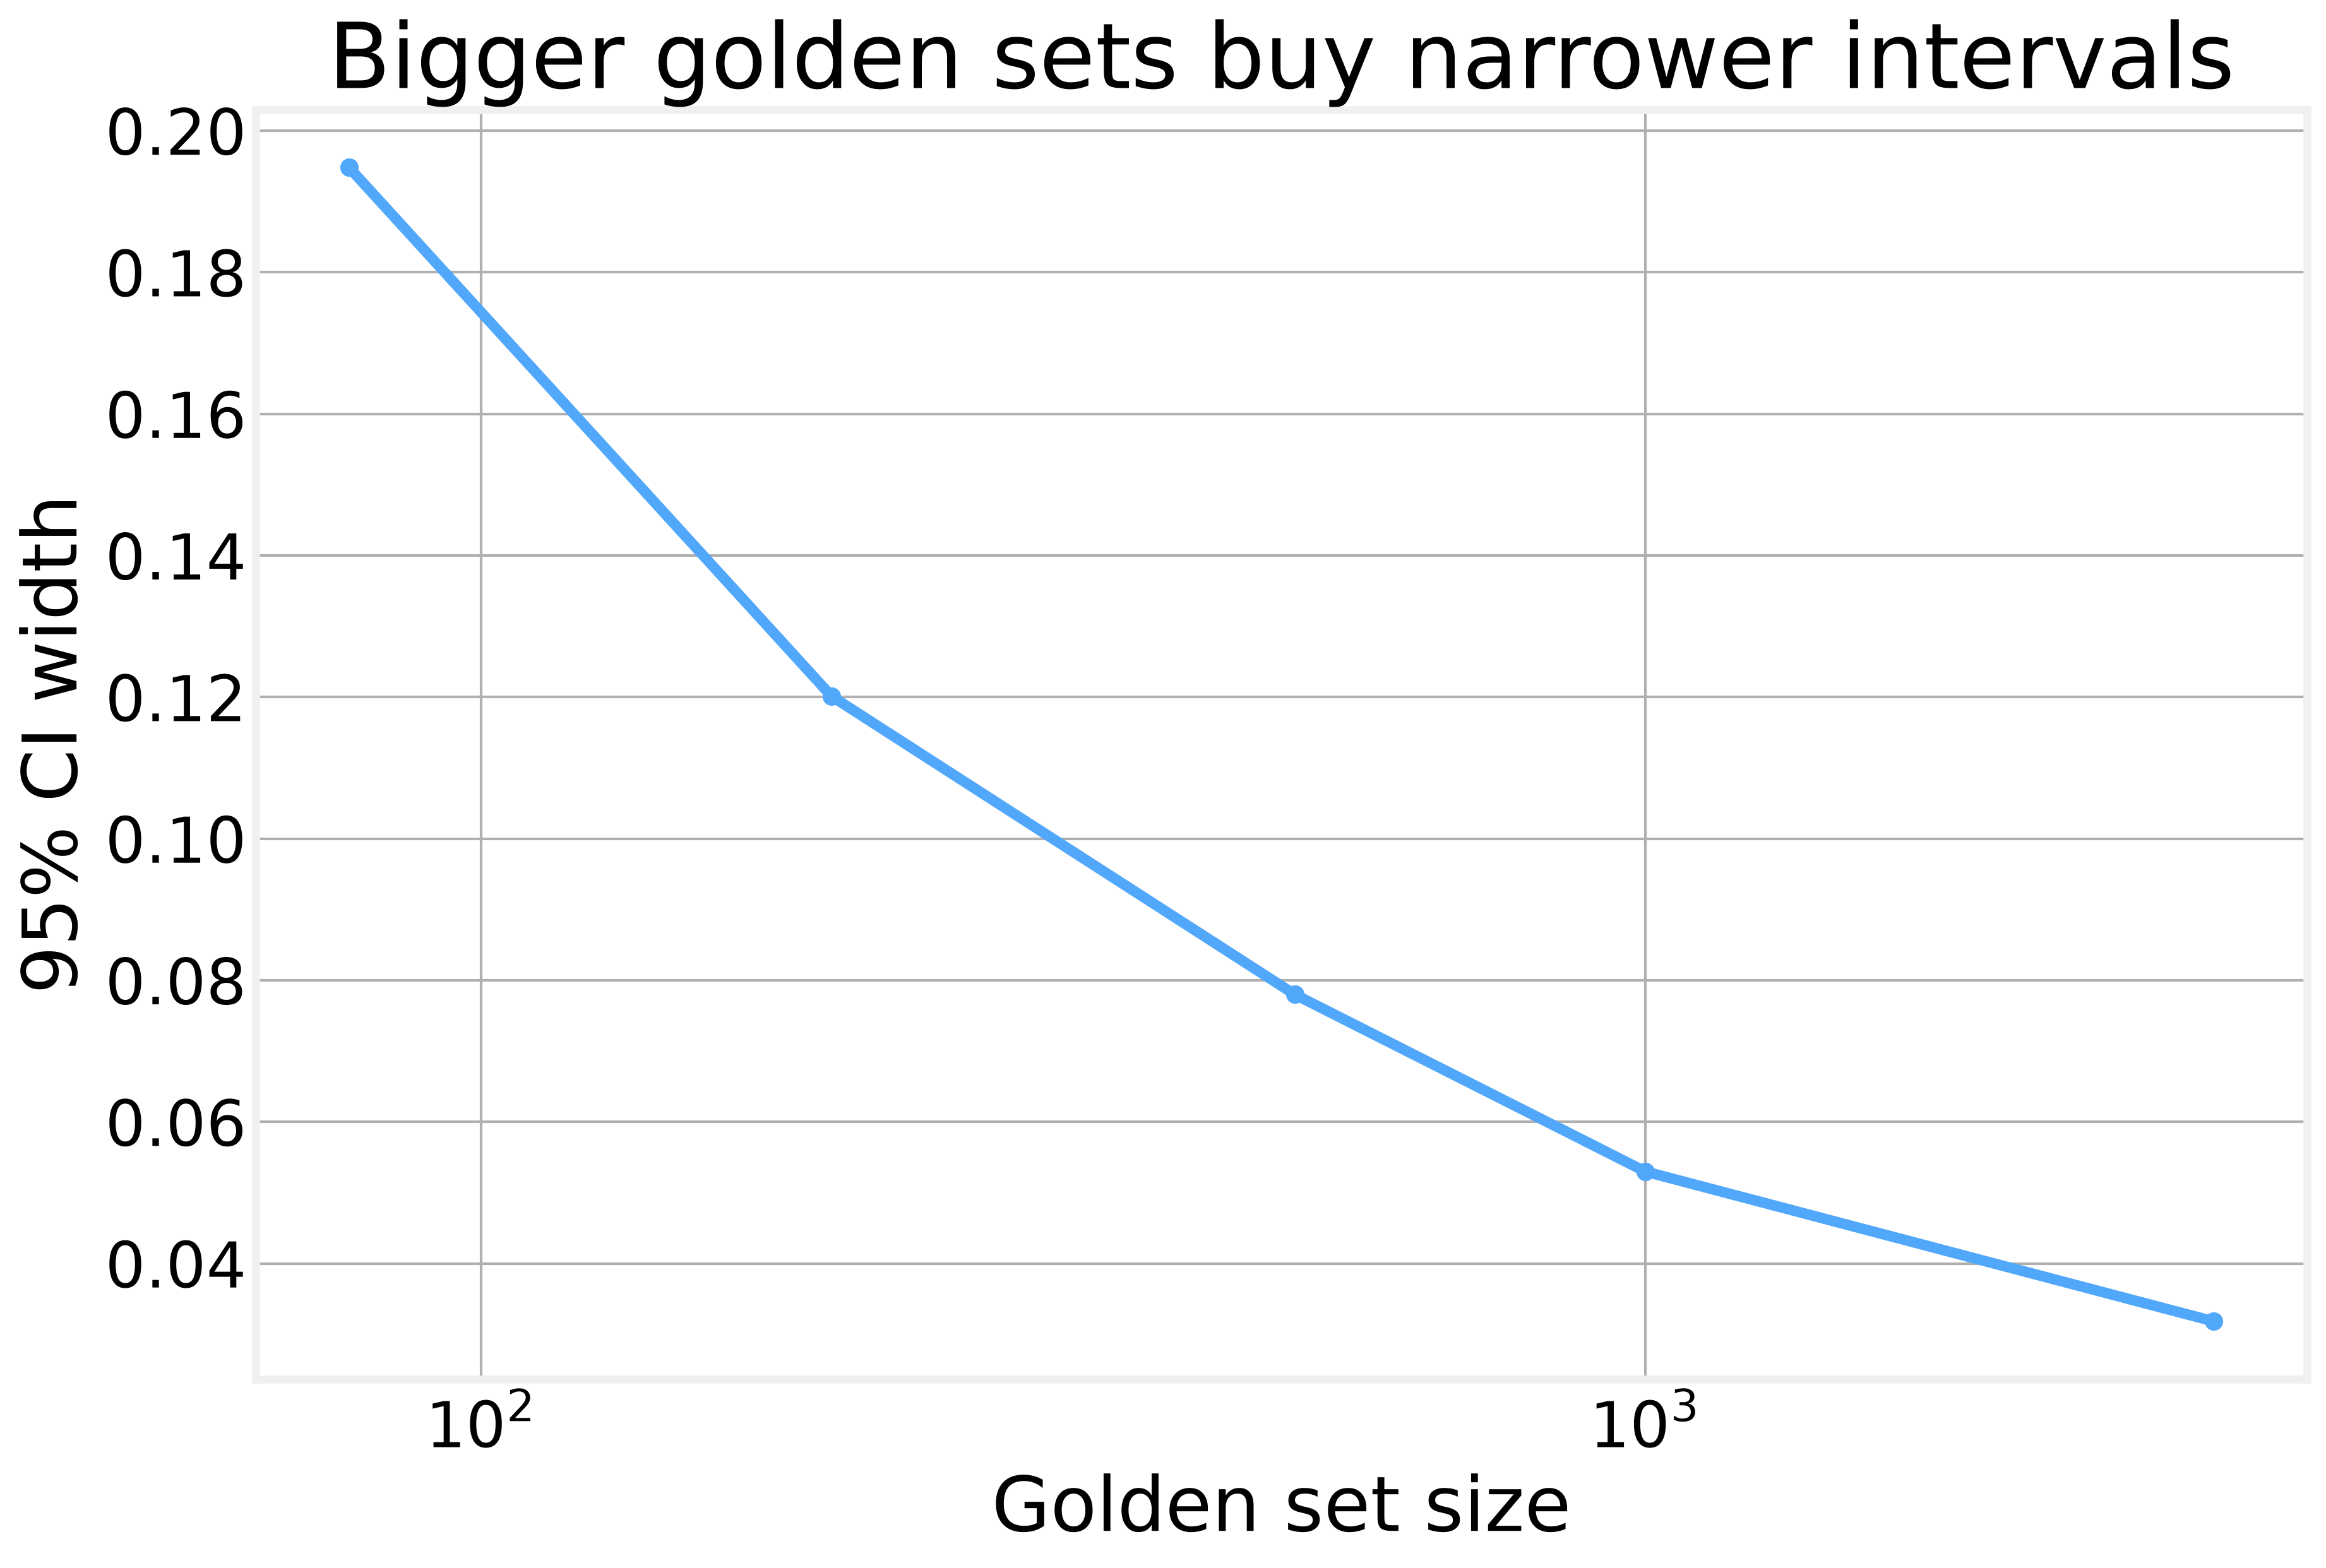

In [11]:
sizes = [77, 200, 500, 1000, 3080]  # 3,080 is the whole Banking77 test split
widths = []

for n in sizes:
    samples = rng.binomial(1, accuracy_a, size=(2000, n)).mean(axis=1)
    low, high = np.quantile(samples, [0.025, 0.975])
    widths.append(high - low)

fig, ax = plt.subplots()
ax.plot(sizes, widths, "o-", color=colors[0])
ax.set_xscale("log")
ax.set_xlabel("Golden set size")
ax.set_ylabel("95% CI width")
ax.set_title("Bigger golden sets buy narrower intervals")
fig.tight_layout()

pd.DataFrame({"n": sizes, "ci_width": np.round(widths, 3)})

# Add the columns that decide

Accuracy alone never decides a production rollout. Cost and latency sit at the same table.

In [12]:
PRICE_PER_1M = {  # USD per million tokens. Prices move. Check your provider page before deciding.
    "gpt-4.1-mini": {"in": 0.40, "out": 1.60},
    "gpt-4.1-nano": {"in": 0.10, "out": 0.40},
}

def cost_per_1k_messages(results, model):
    price = PRICE_PER_1M[model]
    per_message = (results["tokens_in"].mean() * price["in"]
                   + results["tokens_out"].mean() * price["out"]) / 1e6
    return 1000 * per_message

decision = pd.DataFrame({
    MODEL_A: {
        "queue_accuracy": results_a["queue_ok"].mean(),
        "intent_accuracy": accuracy_a,
        "usd_per_1k_messages": cost_per_1k_messages(results_a, MODEL_A),
        "latency_p95_s": results_a["latency_s"].quantile(0.95),
    },
    MODEL_B: {
        "queue_accuracy": results_b["queue_ok"].mean(),
        "intent_accuracy": accuracy_b,
        "usd_per_1k_messages": cost_per_1k_messages(results_b, MODEL_B),
        "latency_p95_s": results_b["latency_s"].quantile(0.95),
    },
}).T.round(3)

decision

,queue_accuracy,intent_accuracy,usd_per_1k_messages,latency_p95_s
gpt-4.1-mini,0.792,0.753,0.491,1.272
gpt-4.1-nano,0.662,0.558,0.123,0.844


### The decision memo

Every model decision fits in four lines. Write them down and attach the eval report:

1. **Claim**: model B matches A on intent accuracy within [x, y] at 95% confidence.
2. **Evidence**: paired bootstrap on golden set v1, n=77, McNemar p=z.
3. **Cost**: B runs at a quarter of the price and half the p95 latency.
4. **Decision**: ship B behind the regression gate from Notebook 6.

### Exercise: buy a narrower interval

Go back to Notebook 2, set `N_PER_INTENT = 5` and regenerate the golden set (385 rows). Re-run this notebook. How much did the CI shrink? Did the decision change?

In [13]:
# Your code here
# golden = pd.read_json(_DATA / 'golden_banking77.jsonl', lines=True)


# Recap

1. Accuracy on a small set is a distribution. Report the interval, not the point.
2. Pair the comparison. Per item differences cancel shared difficulty.
3. McNemar gives a classical p value from the disagreements alone.
4. Put cost and latency in the same table as quality. That table is the decision.

Next: the same discipline applied to retrieval.

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>